# 📦 04 – Clustering & Analisis Pola (K-Means)
**Proyek:** AI-Based Pharmaceutical Data Selection & Monitoring  
**Tim:** PJK-GM016 | Pijak × IBM SkillsBuild  
**Minggu:** 4 – Clustering, Feature Importance & Analisis Korelasi Lanjutan

---
### Alur Notebook
| # | Langkah |
|---|---------|
| 1 | Import & Load Data |
| 2 | Persiapan Fitur Clustering |
| 3 | Elbow Method – Tentukan K Optimal |
| 4 | K-Means Clustering |
| 5 | Profil Setiap Klaster |
| 6 | Visualisasi PCA 2D |
| 7 | Analisis Korelasi Lanjutan |
| 8 | Feature Importance dari Model RF |
| 9 | Identifikasi Klaster High-Defect |
| 10 | Insight & Rekomendasi Actionable |
| 11 | Simpan Hasil |

> ⚠️ Jalankan **03_modeling.ipynb** terlebih dahulu agar file model & prediksi tersedia.


## ⚙️ 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
PALETTE_CLUSTER = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
print("✅ Library siap")

✅ Library siap


## 📂 2. Load Data & Persiapan Fitur Clustering

In [2]:
# Load data dengan prediksi dari notebook 3
try:
    df = pd.read_csv("rekap_produksi_with_predictions.csv", low_memory=False)
    print("✅ Loaded: rekap_produksi_with_predictions.csv")
except FileNotFoundError:
    df = pd.read_csv("rekap_produksi_clean.csv", low_memory=False)
    print("⚠️  File prediksi tidak ditemukan, menggunakan data clean")

print(f"Shape: {df.shape}")
print(f"Defect rate: {df['Defect_Overall'].mean()*100:.2f}%")

# Fitur untuk clustering (hanya numerik bermakna)
CLUSTER_FEATURES = [
    'GB_Yield_Total',
    'GK_Yield_Total',
    'Rasio_GK_GB',
    'GB_Kadar_Air_Mean',
    'Cetak_Yield_Kg',
    'Cetak_Pct_Teoritis',
    'Kemas_Pct_Teoritis',
    'Total_Waste_Kg',
    'Cetak_Durasi_Hari',
    'Kemas_Durasi_Hari',
    'Bulan_Produksi',
]
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in df.columns]

df_cluster = df[CLUSTER_FEATURES + ['Defect_Overall', 'Material_Description']].dropna()
print(f"\nData untuk clustering: {len(df_cluster)} baris")
print(f"Fitur clustering ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}")

scaler_cl = StandardScaler()
X_scaled  = scaler_cl.fit_transform(df_cluster[CLUSTER_FEATURES])
print("\n✅ Data terskalakan (StandardScaler)")

✅ Loaded: rekap_produksi_with_predictions.csv
Shape: (662, 71)
Defect rate: 7.25%

Data untuk clustering: 620 baris
Fitur clustering (11): ['GB_Yield_Total', 'GK_Yield_Total', 'Rasio_GK_GB', 'GB_Kadar_Air_Mean', 'Cetak_Yield_Kg', 'Cetak_Pct_Teoritis', 'Kemas_Pct_Teoritis', 'Total_Waste_Kg', 'Cetak_Durasi_Hari', 'Kemas_Durasi_Hari', 'Bulan_Produksi']

✅ Data terskalakan (StandardScaler)


## 📈 3. Elbow Method – Tentukan K Optimal

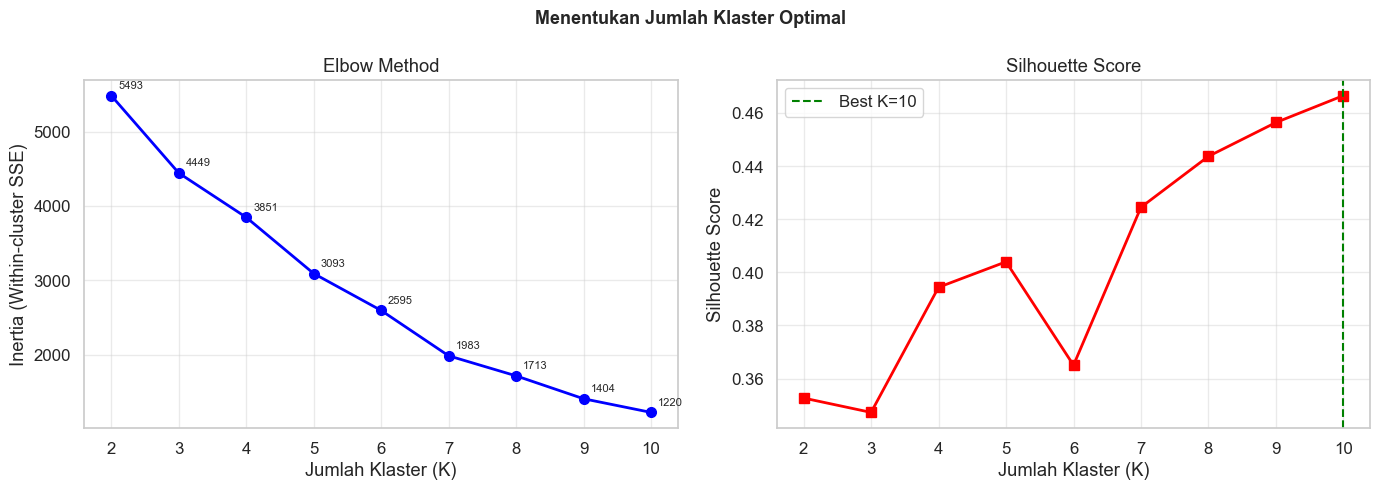


🏆 K optimal (silhouette tertinggi): K = 10
   Silhouette Score: 0.4667


In [3]:
# Hitung inertia dan silhouette untuk berbagai nilai K
K_range     = range(2, 11)
inertias    = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=min(500, len(X_scaled))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Menentukan Jumlah Klaster Optimal", fontsize=13, fontweight='bold')

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', markersize=7, linewidth=2)
axes[0].set_xlabel("Jumlah Klaster (K)"); axes[0].set_ylabel("Inertia (Within-cluster SSE)")
axes[0].set_title("Elbow Method"); axes[0].grid(True, alpha=0.4)
for k, v in zip(K_range, inertias):
    axes[0].annotate(f'{v:.0f}', (k, v), textcoords="offset points", xytext=(5, 5), fontsize=8)

# Silhouette
axes[1].plot(list(K_range), silhouettes, 'rs-', markersize=7, linewidth=2)
axes[1].set_xlabel("Jumlah Klaster (K)"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score"); axes[1].grid(True, alpha=0.4)
best_k = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k, color='green', linestyle='--', lw=1.5, label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 K optimal (silhouette tertinggi): K = {best_k}")
print(f"   Silhouette Score: {max(silhouettes):.4f}")

## 🎯 4. K-Means Clustering dengan K Optimal

In [4]:
# Gunakan K = 3 (sesuai project plan) atau best_k dari silhouette
K_FINAL = 3   # Bisa diganti dengan best_k
print(f"K yang digunakan: {K_FINAL}")

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20, max_iter=500)
cluster_labels = kmeans.fit_predict(X_scaled)

df_cluster = df_cluster.copy()
df_cluster['Cluster'] = cluster_labels

print(f"\nDistribusi klaster:")
for k in range(K_FINAL):
    n      = (cluster_labels == k).sum()
    n_def  = df_cluster.loc[df_cluster['Cluster']==k, 'Defect_Overall'].sum()
    dr     = n_def/n*100 if n > 0 else 0
    print(f"  Klaster {k}: {n:4d} baris | Defect: {int(n_def):3d} ({dr:.1f}%)")

print(f"\nSilhouette Score (K={K_FINAL}): {silhouette_score(X_scaled, cluster_labels):.4f}")

K yang digunakan: 3

Distribusi klaster:
  Klaster 0:  198 baris | Defect:   4 (2.0%)
  Klaster 1:    2 baris | Defect:   0 (0.0%)
  Klaster 2:  420 baris | Defect:  12 (2.9%)

Silhouette Score (K=3): 0.3591


## 📋 5. Profil Setiap Klaster

In [5]:
# Statistik rata-rata per klaster
profile_cols = CLUSTER_FEATURES + ['Defect_Overall']
cluster_profile = df_cluster.groupby('Cluster')[profile_cols].mean().round(3)
cluster_profile['Jumlah_Batch'] = df_cluster.groupby('Cluster').size()
cluster_profile['Defect_Rate_%'] = (df_cluster.groupby('Cluster')['Defect_Overall'].mean() * 100).round(2)

print("📊 Profil Rata-rata per Klaster:")
print(cluster_profile.T.to_string())

# Label klaster berdasarkan defect rate
defect_rates = cluster_profile['Defect_Rate_%']
labels_map   = {}
sorted_k     = defect_rates.sort_values(ascending=False).index.tolist()
risk_names   = ['🔴 High Risk', '🟡 Medium Risk', '🟢 Low Risk'] + [f'Klaster {i}' for i in range(10)]
for i, k in enumerate(sorted_k):
    labels_map[k] = risk_names[i] if i < len(risk_names) else f'Klaster {k}'
    print(f"\n  Klaster {k} → {risk_names[i]}: Defect Rate = {defect_rates[k]:.1f}%")

df_cluster['Cluster_Label'] = df_cluster['Cluster'].map(labels_map)

📊 Profil Rata-rata per Klaster:
Cluster                   0        1        2
GB_Yield_Total      623.346  427.445  601.094
GK_Yield_Total      965.593  920.825  351.624
Rasio_GK_GB           1.568    2.154    0.641
GB_Kadar_Air_Mean     3.724    5.470    4.732
Cetak_Yield_Kg      935.253  732.500  766.998
Cetak_Pct_Teoritis    0.967    2.907    0.971
Kemas_Pct_Teoritis    0.969    2.857    0.960
Total_Waste_Kg        0.000    0.000   11.278
Cetak_Durasi_Hari     0.566    1.000    0.748
Kemas_Durasi_Hari     1.106    0.500    2.071
Bulan_Produksi        4.995    6.000    4.719
Defect_Overall        0.020    0.000    0.029
Jumlah_Batch        198.000    2.000  420.000
Defect_Rate_%         2.020    0.000    2.860

  Klaster 2 → 🔴 High Risk: Defect Rate = 2.9%

  Klaster 0 → 🟡 Medium Risk: Defect Rate = 2.0%

  Klaster 1 → 🟢 Low Risk: Defect Rate = 0.0%


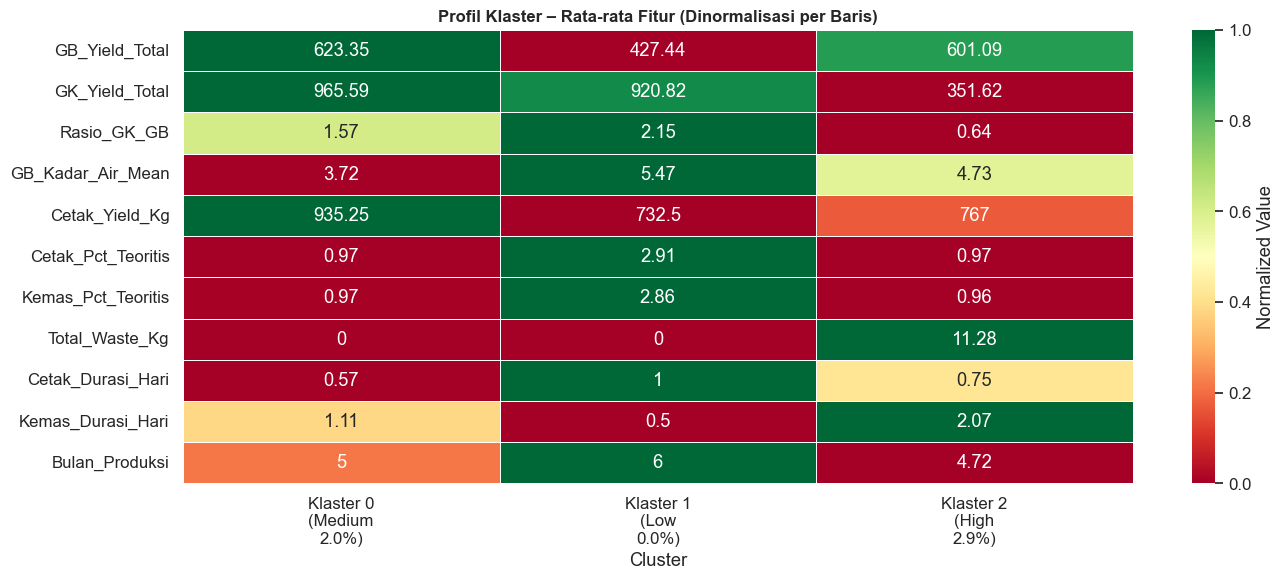

In [6]:
# Heatmap profil klaster
fig, ax = plt.subplots(figsize=(14, 6))
profile_norm = cluster_profile[CLUSTER_FEATURES].T
# Normalize per baris
profile_norm = profile_norm.apply(lambda x: (x - x.min())/(x.max()-x.min()+1e-9), axis=1)
sns.heatmap(profile_norm, annot=cluster_profile[CLUSTER_FEATURES].T.round(2),
            fmt='g', cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Normalized Value'})
ax.set_title("Profil Klaster – Rata-rata Fitur (Dinormalisasi per Baris)",
             fontweight='bold', fontsize=12)
ax.set_xticklabels([f'Klaster {k}\n({labels_map[k].split()[1]}\n{defect_rates[k]:.1f}%)'
                    for k in range(K_FINAL)], rotation=0)
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ 6. Visualisasi PCA 2D

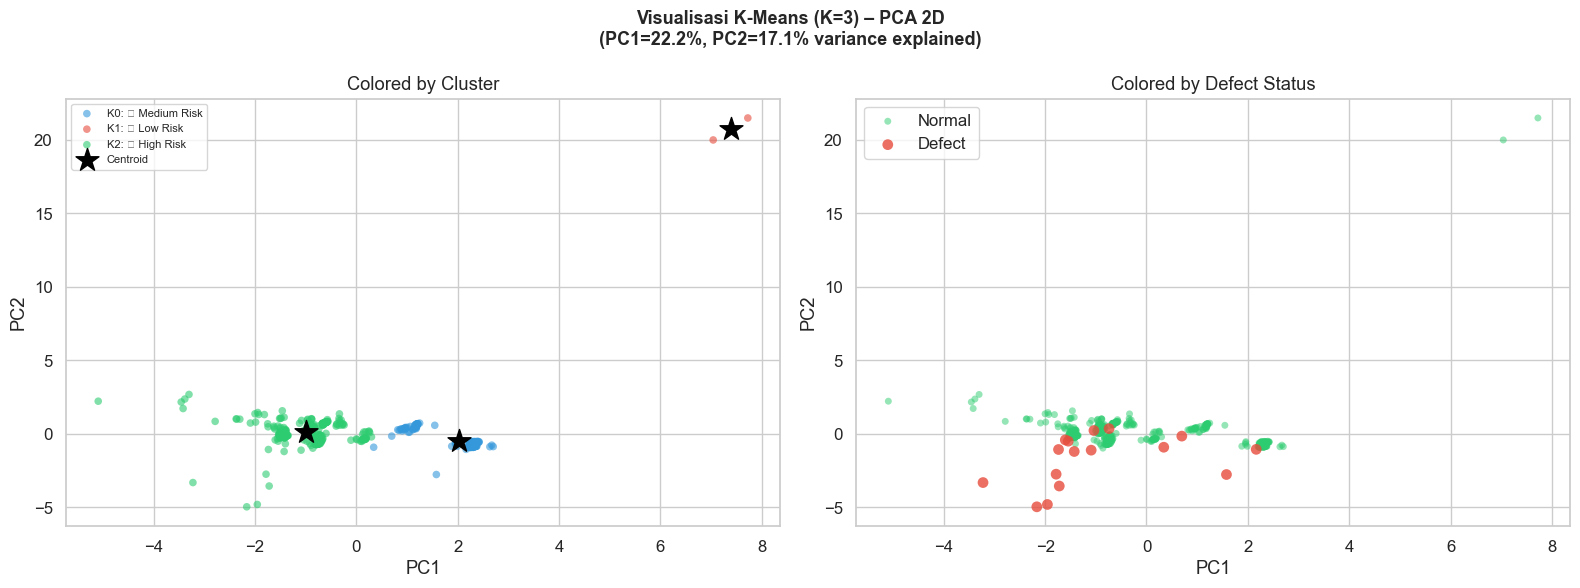

✅ Total variance explained: 39.3%


In [7]:
# Reduksi ke 2D dengan PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

df_cluster['PCA1'] = X_pca[:, 0]
df_cluster['PCA2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Visualisasi K-Means (K={K_FINAL}) – PCA 2D\n"
             f"(PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}% variance explained)",
             fontsize=13, fontweight='bold')

# Plot by Cluster
for k in range(K_FINAL):
    mask = df_cluster['Cluster'] == k
    axes[0].scatter(df_cluster.loc[mask, 'PCA1'], df_cluster.loc[mask, 'PCA2'],
                    c=PALETTE_CLUSTER[k], label=f'K{k}: {labels_map[k]}',
                    s=30, alpha=0.6, edgecolors='none')
# Centroid
centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1],
                c='black', marker='*', s=300, zorder=10, label='Centroid')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("Colored by Cluster")
axes[0].legend(fontsize=8)

# Plot by Defect
for kelas, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Defect')]:
    mask = df_cluster['Defect_Overall'] == kelas
    axes[1].scatter(df_cluster.loc[mask, 'PCA1'], df_cluster.loc[mask, 'PCA2'],
                    c=color, label=label, s=25 if kelas==0 else 60,
                    alpha=0.5 if kelas==0 else 0.8, edgecolors='none',
                    zorder=5 if kelas==1 else 3)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Colored by Defect Status")
axes[1].legend()

plt.tight_layout()
plt.savefig("pca_clustering.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Total variance explained: {sum(var_exp)*100:.1f}%")

## 🔥 7. Analisis Korelasi Lanjutan

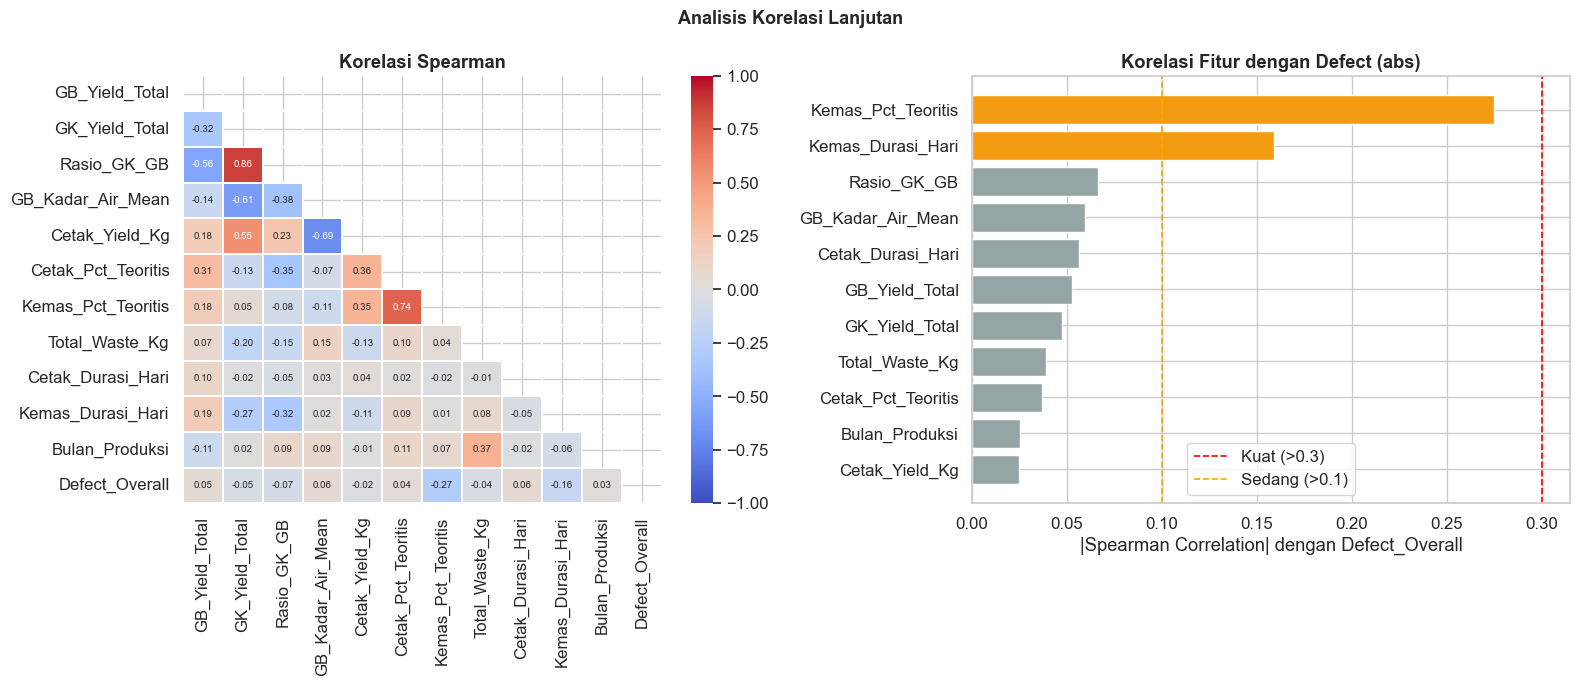

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Analisis Korelasi Lanjutan", fontsize=13, fontweight='bold')

# ── A. Korelasi Spearman ──────────────────────────────────────────
corr_spear = df_cluster[CLUSTER_FEATURES + ['Defect_Overall']].corr(method='spearman')
mask = np.triu(np.ones_like(corr_spear, dtype=bool))
sns.heatmap(corr_spear, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=axes[0], annot_kws={'size':7})
axes[0].set_title("Korelasi Spearman", fontweight='bold')

# ── B. Pairplot top 4 fitur vs defect ────────────────────────────
top4 = ['Cetak_Pct_Teoritis', 'Kemas_Pct_Teoritis',
        'GB_Yield_Total', 'Total_Waste_Kg']
top4 = [c for c in top4 if c in df_cluster.columns]

corr_with_defect = df_cluster[CLUSTER_FEATURES].corrwith(
    df_cluster['Defect_Overall'], method='spearman').abs().sort_values(ascending=True)
colors_corr = ['#e74c3c' if v > 0.3 else '#f39c12' if v > 0.1 else '#95a5a6'
               for v in corr_with_defect.values]
axes[1].barh(corr_with_defect.index, corr_with_defect.values, color=colors_corr, edgecolor='white')
axes[1].set_xlabel("|Spearman Correlation| dengan Defect_Overall")
axes[1].set_title("Korelasi Fitur dengan Defect (abs)", fontweight='bold')
axes[1].axvline(0.3, color='red', linestyle='--', lw=1.2, label='Kuat (>0.3)')
axes[1].axvline(0.1, color='orange', linestyle='--', lw=1.2, label='Sedang (>0.1)')
axes[1].legend()

plt.tight_layout()
plt.savefig("korelasi_lanjutan.png", dpi=150, bbox_inches='tight')
plt.show()

## 🏆 8. Feature Importance dari Model RF

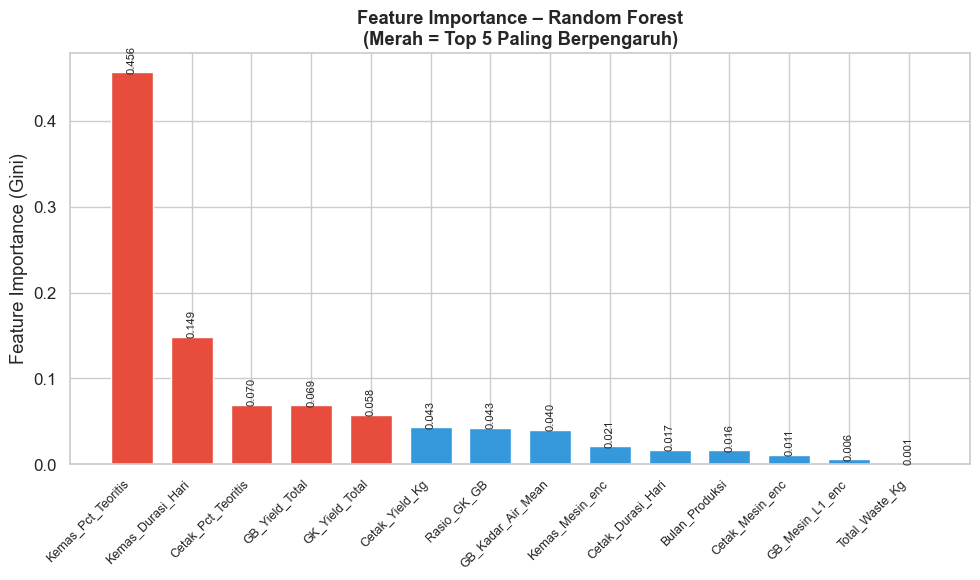


🏆 Feature Importance Ranking:
   1. Kemas_Pct_Teoritis             0.4565  ███████████████████████████████████████████████████████████████████████████████████████████
   2. Kemas_Durasi_Hari              0.1488  █████████████████████████████
   3. Cetak_Pct_Teoritis             0.0696  █████████████
   4. GB_Yield_Total                 0.0690  █████████████
   5. GK_Yield_Total                 0.0579  ███████████
   6. Cetak_Yield_Kg                 0.0433  ████████
   7. Rasio_GK_GB                    0.0427  ████████
   8. GB_Kadar_Air_Mean              0.0400  ████████
   9. Kemas_Mesin_enc                0.0210  ████
  10. Cetak_Durasi_Hari              0.0170  ███
  11. Bulan_Produksi                 0.0163  ███
  12. Cetak_Mesin_enc                0.0113  ██
  13. GB_Mesin_L1_enc                0.0056  █
  14. Total_Waste_Kg                 0.0009  


In [9]:
try:
    rf_model = joblib.load('models/random_forest_model.pkl')
    with open('models/feature_cols.txt') as f:
        feature_names = f.read().splitlines()

    importances = pd.Series(rf_model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_fi = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(importances))]
    bars = ax.bar(range(len(importances)), importances.values,
                  color=colors_fi, edgecolor='white', width=0.7)
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels(importances.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Feature Importance (Gini)")
    ax.set_title("Feature Importance – Random Forest\n(Merah = Top 5 Paling Berpengaruh)",
                 fontweight='bold')
    for bar, val in zip(bars, importances.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.3f}', ha='center', fontsize=8, rotation=90)
    plt.tight_layout()
    plt.savefig("feature_importance_bar.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\n🏆 Feature Importance Ranking:")
    for i, (feat, val) in enumerate(importances.items()):
        bar_vis = "█" * int(val * 200)
        print(f"  {i+1:2d}. {feat:30s} {val:.4f}  {bar_vis}")

except FileNotFoundError:
    print("⚠️  Model belum ditemukan. Jalankan 03_modeling.ipynb terlebih dahulu.")
    print("   Menampilkan korelasi sebagai proxy feature importance...")
    corr_proxy = df_cluster[CLUSTER_FEATURES].corrwith(
        df_cluster['Defect_Overall'], method='spearman').abs().sort_values(ascending=False)
    print(corr_proxy.to_string())

## ⚠️ 9. Identifikasi & Analisis Klaster High-Defect

🔴 Klaster High-Defect: Klaster 2
   Defect Rate: 2.9%



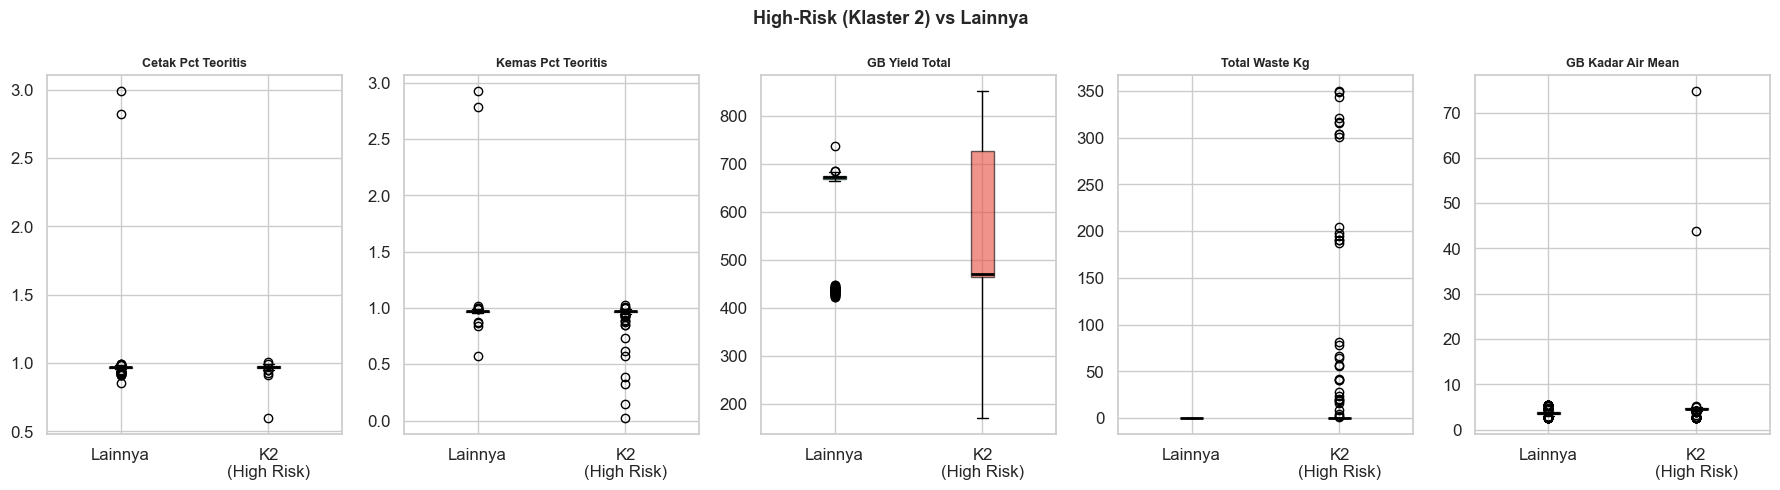


📦 Produk dominan di klaster High-Risk:
Material_Description
BODREX EXTRA KAPLET/4'S               196
BODREX MIGRA / 4 KAPLET                95
BODREX FLU & BATUK PE/4'S              82
FORPAIN KAPLET/20E NF                  27
BODREX FLU & BATUK BERDAHAK PE/4'S     14


In [10]:
# Temukan klaster dengan defect rate tertinggi
high_defect_k = defect_rates.idxmax()
print(f"🔴 Klaster High-Defect: Klaster {high_defect_k}")
print(f"   Defect Rate: {defect_rates[high_defect_k]:.1f}%\n")

high_risk_df   = df_cluster[df_cluster['Cluster'] == high_defect_k]
low_risk_df    = df_cluster[df_cluster['Cluster'] != high_defect_k]

# Perbandingan statistik
compare_cols = ['Cetak_Pct_Teoritis','Kemas_Pct_Teoritis',
                'GB_Yield_Total','Total_Waste_Kg','GB_Kadar_Air_Mean']
compare_cols = [c for c in compare_cols if c in df_cluster.columns]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(18, 5))
fig.suptitle(f"High-Risk (Klaster {high_defect_k}) vs Lainnya",
             fontsize=13, fontweight='bold')

for i, col in enumerate(compare_cols):
    data_hr = high_risk_df[col].dropna()
    data_lr = low_risk_df[col].dropna()
    axes[i].boxplot([data_lr, data_hr], labels=['Lainnya', f'K{high_defect_k}\n(High Risk)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col.replace('_',' '), fontsize=9, fontweight='bold')

# Override warna kotak kedua (high-risk = merah)
for i in range(len(compare_cols)):
    patches = [p for p in axes[i].patches if hasattr(p, 'get_facecolor')]
    if len(patches) > 1:
        patches[1].set_facecolor('#e74c3c')
        patches[1].set_alpha(0.6)

plt.tight_layout()
plt.savefig("high_risk_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Produk dominan di high-risk
print("\n📦 Produk dominan di klaster High-Risk:")
print(high_risk_df['Material_Description'].value_counts().head(5).to_string())

## 💡 10. Insight & Rekomendasi Actionable

In [11]:
print("=" * 65)
print("  INSIGHT & REKOMENDASI – PJK-GM016")
print("=" * 65)

print(f"\n📊 RINGKASAN CLUSTERING (K={K_FINAL}):")
for k in range(K_FINAL):
    n   = (df_cluster['Cluster']==k).sum()
    dr  = defect_rates[k]
    lbl = labels_map[k]
    print(f"   Klaster {k} [{lbl:20s}]: {n:4d} batch, Defect={dr:.1f}%")

print(f"\n🔑 FAKTOR UTAMA PENYEBAB DEFECT (dari analisis korelasi & klaster):")
corr_final = df_cluster[CLUSTER_FEATURES].corrwith(
    df_cluster['Defect_Overall'], method='spearman').abs().sort_values(ascending=False)
for i, (feat, val) in enumerate(corr_final.items()):
    if i >= 5: break
    lvl = "TINGGI" if val>0.3 else "SEDANG" if val>0.1 else "RENDAH"
    print(f"   {i+1}. {feat:30s} → Korelasi: {val:.3f} [{lvl}]")

hr  = df_cluster[df_cluster['Cluster']==high_defect_k]
print(f"\n⚠️  KARAKTERISTIK KLASTER HIGH-RISK (K={high_defect_k}):")
for col in ['Cetak_Pct_Teoritis','Kemas_Pct_Teoritis','Total_Waste_Kg']:
    if col in hr.columns:
        print(f"   {col:30s}: Mean={hr[col].mean():.3f}, Std={hr[col].std():.3f}")

print(f"\n🎯 REKOMENDASI OPERASIONAL:")
print(f"   1. Fokus monitoring pada batch di Klaster {high_defect_k} ({labels_map[high_defect_k]})")
print(f"   2. Tingkatkan QC pada proses Cetak & Kemas (korelasi tertinggi dengan defect)")
print(f"   3. Terapkan alert otomatis jika % teoritis < 90%")
print(f"   4. Analisis ulang kondisi mesin pada batch dengan Total_Waste_Kg tinggi")
print(f"   5. Integrasikan prediksi model RF ke dashboard untuk monitoring real-time")
print("=" * 65)
print("\n✅ Selesai! Lanjut ke 05_dashboard.ipynb")

  INSIGHT & REKOMENDASI – PJK-GM016

📊 RINGKASAN CLUSTERING (K=3):
   Klaster 0 [🟡 Medium Risk       ]:  198 batch, Defect=2.0%
   Klaster 1 [🟢 Low Risk          ]:    2 batch, Defect=0.0%
   Klaster 2 [🔴 High Risk         ]:  420 batch, Defect=2.9%

🔑 FAKTOR UTAMA PENYEBAB DEFECT (dari analisis korelasi & klaster):
   1. Kemas_Pct_Teoritis             → Korelasi: 0.275 [SEDANG]
   2. Kemas_Durasi_Hari              → Korelasi: 0.159 [SEDANG]
   3. Rasio_GK_GB                    → Korelasi: 0.066 [RENDAH]
   4. GB_Kadar_Air_Mean              → Korelasi: 0.060 [RENDAH]
   5. Cetak_Durasi_Hari              → Korelasi: 0.056 [RENDAH]

⚠️  KARAKTERISTIK KLASTER HIGH-RISK (K=2):
   Cetak_Pct_Teoritis            : Mean=0.971, Std=0.020
   Kemas_Pct_Teoritis            : Mean=0.960, Std=0.081
   Total_Waste_Kg                : Mean=11.278, Std=52.371

🎯 REKOMENDASI OPERASIONAL:
   1. Fokus monitoring pada batch di Klaster 2 (🔴 High Risk)
   2. Tingkatkan QC pada proses Cetak & Kemas (korelasi 

## 💾 11. Simpan Hasil Clustering

In [12]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(kmeans,    'models/kmeans_model.pkl')
joblib.dump(scaler_cl, 'models/scaler_clustering.pkl')
joblib.dump(pca,       'models/pca_model.pkl')

with open('models/cluster_features.txt', 'w') as f:
    f.write('\n'.join(CLUSTER_FEATURES))

# Simpan label map
import json
with open('models/cluster_labels_map.json', 'w') as f:
    json.dump({str(k): v for k,v in labels_map.items()}, f, indent=2)

# Simpan dataframe dengan cluster labels
df_cluster.to_csv("rekap_produksi_clustered.csv", index=False)

print("✅ Semua artefak clustering tersimpan:")
for fname in ['models/kmeans_model.pkl','models/scaler_clustering.pkl',
              'models/pca_model.pkl','models/cluster_features.txt',
              'models/cluster_labels_map.json','rekap_produksi_clustered.csv']:
    import os
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f"   {fname:45s} ({size:,} bytes)")

✅ Semua artefak clustering tersimpan:
   models/kmeans_model.pkl                       (3,479 bytes)
   models/scaler_clustering.pkl                  (1,279 bytes)
   models/pca_model.pkl                          (1,271 bytes)
   models/cluster_features.txt                   (188 bytes)
   models/cluster_labels_map.json                (106 bytes)
   rekap_produksi_clustered.csv                  (111,332 bytes)
